# Evaluating Random Forest Performance

### implement and evaluate the performance of random forest regression model

### Interpret various metrics and visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew

<h3 style = 'color: red'>Load the dataset</h3>

In [2]:
data = fetch_california_housing()
x, y = data.data, data.target

In [3]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

<h3 style = 'color: red'>Spalit the data</h3>

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

<h3 style = 'color: red'>Explore the training data</h3>

In [5]:
eda = pd.DataFrame(data = x_train)
eda.columns = data.feature_names
eda['MedHouseVal'] = y_train
eda.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
eda.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,1.030
1,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,3.821
2,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,1.726
3,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,0.934
4,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,0.965


<h3 style = 'color: red'>median house prices distributed</h3>

Text(0, 0.5, 'Frequency')

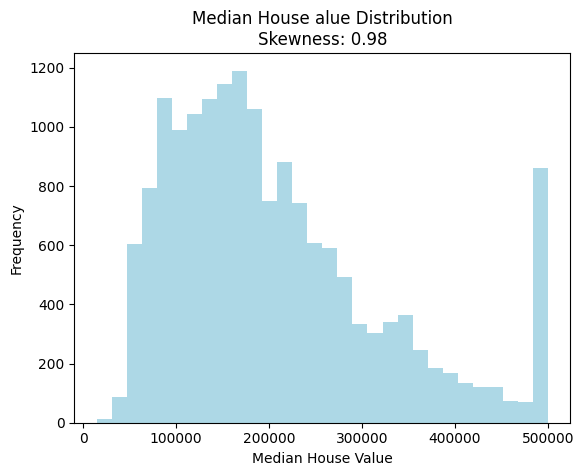

In [7]:
# plot the distribution
plt.hist(1e5 * y_train, bins = 30, color = 'lightblue', ec = 'black')
plt.title(f'Median House alue Distribution\nSkewness: {skew(y_train):.2f}')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

<h3 style = 'color: red'>Model fitting and prediction</h3>

In [8]:
# initiate and fit the random forest regressor
rf_regressor = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_regressor.fit(x_train, y_train)
# predict on the test
y_pred_test = rf_regressor.predict(x_test)

<h3 style = 'color: red'>Estimation</h3>

In [10]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R^2: {r2:.4f}')

MAE: 0.3275
MSE: 0.2554
RMSE: 0.5053
R^2: 0.8051


<h3 style = 'color: red'>Plot actual vs predicted values</h3>

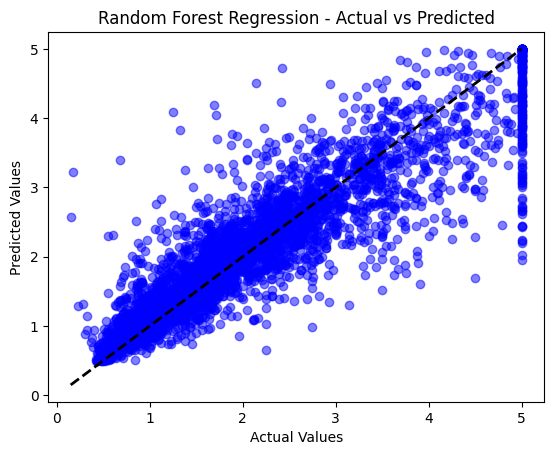

In [11]:
plt.scatter(y_test, y_pred_test, alpha = 0.5, color = 'blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw = 2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Regression - Actual vs Predicted')
plt.show()

<h3 style = 'color: red'>Plot the histogram of the residual errors (dollars)</h3>

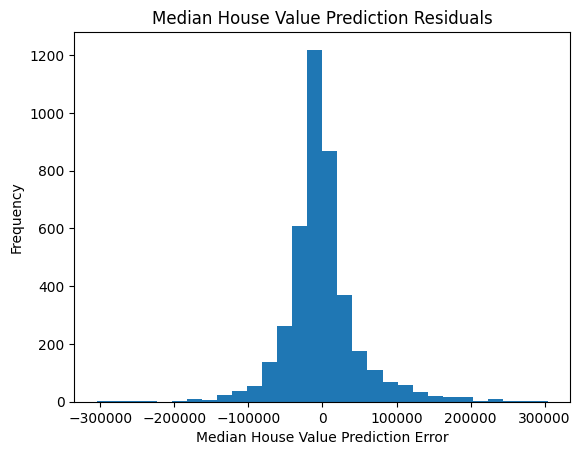

In [13]:
residuals = 1e5 * (y_test - y_pred_test)
plt.hist(residuals, bins = 30, ec = 'black')
plt.title(f'Median House Value Prediction Residuals')
plt.xlabel('Median House Value Prediction Error')
plt.ylabel('Frequency')
plt.show()

<h3 style = 'color: red'>Plot the model residual errors by median house value</h3>

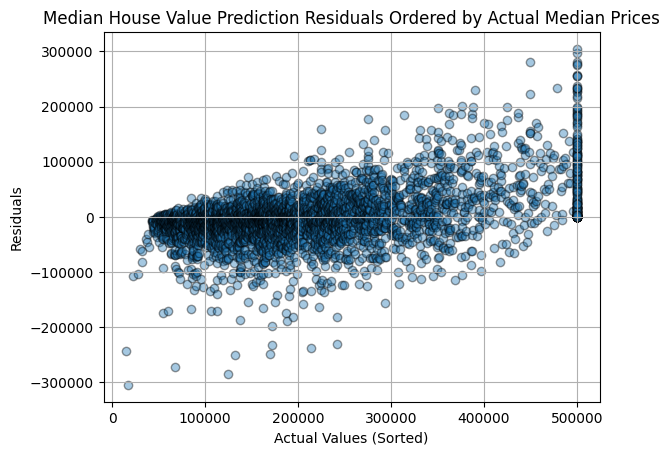

In [15]:
# create a DataFrame to make sorting easy
residual_df = pd.DataFrame({'Actual': 1e5 * y_test, 'Residual': residuals})
# sort the DataFrame by the actual target values
residual_df = residual_df.sort_values(by = 'Actual')
# plot the residual
plt.scatter(residual_df['Actual'], residual_df['Residual'], marker = 'o', alpha = 0.4, ec = 'k')
plt.title('Median House Value Prediction Residuals Ordered by Actual Median Prices')
plt.xlabel('Actual Values (Sorted)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

<h4 style = 'color: yellow'>From above residual plot, we can tell that for those lower prices housing, the model tend to be overpredicted,
and for those higher prices housing, the model tend to be underpredicted</h4>

<h3 style = 'color: red'>Display the feature importances as a bar chart</h3>

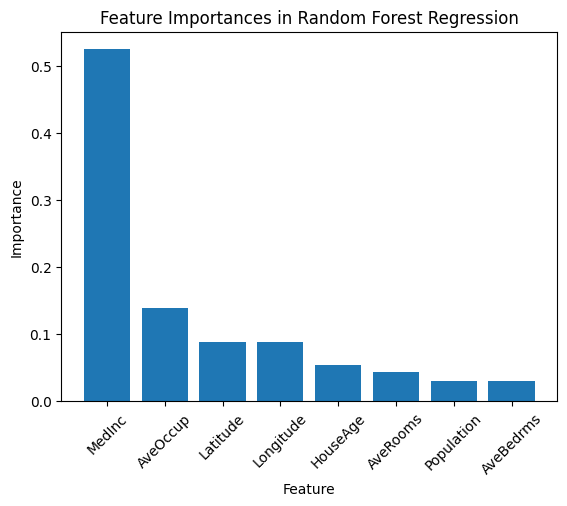

In [24]:
# feature importances
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]     # [::-1] counting from the very last, meaning sorting from the greatest
features = data.feature_names
# plot feature importances
plt.bar(range(x.shape[1]), importances[indices], align = 'center')     # use consecutive numeric value to center bars first
plt.xticks(range(x.shape[1]), [features[i] for i in indices], rotation = 45)     # change xticks for better visualization and interpretation
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances in Random Forest Regression')
plt.show()

<h3 style = 'color: red'>Final thoughts:</h3>
<h3 style = 'color: red'>will the skewness affect the performance of random forest regression?</h3>
<h3 style = 'color: red'>does the clipping of median house prices above $500,000 bias the predictions?</h3>
<h3 style = 'color: red'>do we need to standardize the data?</h3>

Compared to linear regression, random forest regression is quite robust against outliers and skewed distributions. This is because random forest regression doesn't make any assumptions about the data distribution, where linear regression performs best with normally distributed data.
Standardizing the data isn't necessary like it is for distance-based algortihms like KNN or SVMs.

Regarding the clipped vlaues, there is no variablilty in those values. Removing them in preprocessing might help the model to better explain the actual variance in the data.

The clipped values can alsos bias the predictions. Also these clipped values can mislead evaluation metrics. As you've learned from this lab, it's crucially important for you to visualize your results.